# From Sequence Models to Attention — building a TinyGPT

Notebook 04 fed a **bag of characters** into an MLP: reorder the 5 input
characters and the prediction cannot tell the difference. Real language models
need the opposite: every token should **look back** at the tokens before it and
decide *which ones matter*. That mechanism is **self-attention**, and stacking
it gives you a Transformer — the architecture behind GPT.

This notebook builds one from scratch in three steps:

1. **Single-head self-attention** from first principles (NumPy first, then PyTorch) — §2
2. **Stacked Transformer blocks**: multi-head attention + FFN + residuals + LayerNorm — §3
3. **Training** the resulting tiny GPT on short sequences (64 tokens) of Tiny Shakespeare — §4

By the end we generate Shakespeare-like text the same way notebook 04 did, but
with a 64-token context instead of a 5-character one.


## 1. Data & batches (same corpus as notebook 04)

Same character-level vocabulary as before (65 characters). The one real change
is **how batches are built**: instead of one 5-char window → one next
character, we now train on the whole chunk at once. For a chunk
`x = tokens[i:i+T]` the target is simply `y = tokens[i+1:i+1+T]`, so a single
sequence of T=64 tokens yields **64 parallel next-token predictions**.


In [1]:
import math
import os
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
# Seeding = reproducible runs (init, batch sampling). Remove it and
# Seeding = reproducible runs (init, batch sampling). Remove it and
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
# All tensors and the model get .to(device); one flag makes the notebook
# All tensors and the model get .to(device); one flag makes the notebook
print(f"Using device: {device}")


Using device: cpu


In [2]:
def load_shakespeare():
    """Reuse the local copy if it exists, otherwise download Tiny Shakespeare."""
# Local-first loader: reuses dataset/input.txt (or a local copy) and only
# Local-first loader: reuses dataset/input.txt (or a local copy) and only
    for path in ("../dataset/input.txt", "dataset/input.txt", "input.txt"):
        if os.path.exists(path):
            print(f"Loaded dataset from: {path}")
            with open(path, "r", encoding="utf-8") as f:
                return f.read()
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    print(f"Local copy not found, downloading: {url}")
    with urllib.request.urlopen(url) as r:
        return r.read().decode("utf-8")


text = load_shakespeare()
print(f"Dataset length: {len(text):,} characters")
print(text[:200] + "...")


Loaded dataset from: ../dataset/input.txt
Dataset length: 1,115,393 characters
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you...


In [3]:
chars = sorted(set(text))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}
vocab_size = len(chars)

print(f"Character vocab size: {vocab_size}")

# Same encoding as notebook 04, but as one long flat sequence:
# a language model only needs (tokens[0..n-2]) -> (tokens[1..n-1]).
data = torch.tensor([char_to_idx[c] for c in text], dtype=torch.long)
# One long flat id sequence (no windows yet). Language modeling only
# One long flat id sequence (no windows yet). Language modeling only

# 90/10 train/validation split
n_train = int(0.9 * len(data))
# 90/10 split: val_data is NEVER trained on — its loss measures whether
# 90/10 split: val_data is NEVER trained on — its loss measures whether
train_data = data[:n_train]
val_data = data[n_train:]
print(f"Train tokens: {len(train_data):,} | Val tokens: {len(val_data):,}")


Character vocab size: 65
Train tokens: 1,003,853 | Val tokens: 111,540


In [4]:
def get_batch(source, batch_size=32, block_size=64):
# THE BATCHER: random chunk sampling — the shift from notebook 04.
# Each x row is T=64 consecutive ids; y is the same chunk shifted one
# THE BATCHER: random chunk sampling — the shift from notebook 04.
# Each x row is T=64 consecutive ids; y is the same chunk shifted one
    """Sample random chunks: predict every next token in parallel.

    x: (B, T) the current tokens
    y: (B, T) the same tokens shifted by one -> B*T predictions per batch
    (notebook 04 predicted ONE next token per 5-char context.)
    """
    ix = torch.randint(len(source) - block_size - 1, (batch_size,))
# -1 headroom guarantees the shifted slice stays in bounds.
# -1 headroom guarantees the shifted slice stays in bounds.
    x = torch.stack([source[i : i + block_size] for i in ix])
# stack copies the slices into a real (B, T) tensor (slices alone would
# stack copies the slices into a real (B, T) tensor (slices alone would
    y = torch.stack([source[i + 1 : i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)
# .to(device) moves data to GPU if there is one (see cell 2).
# .to(device) moves data to GPU if there is one (see cell 2).


xb, yb = get_batch(train_data)
print(f"x: {tuple(xb.shape)}  y: {tuple(yb.shape)}")
print("context:", repr("".join(idx_to_char[i.item()] for i in xb[0, :24])))
print("target :", repr("".join(idx_to_char[i.item()] for i in yb[0, :24])))


x: (32, 64)  y: (32, 64)
context: ' chance!\nThe lady stirs.'
target : 'chance!\nThe lady stirs.\n'


## 2. Task 1 — single-head self-attention from scratch

**The problem with notebook 04's MLP:** `fc1` sees a flattened one-hot vector.
Shuffle the 5 characters and the same weights hit the same inputs — the model
is *permutation-symmetric* and has no notion of "which character should I look
at". For language we want the opposite: position-aware, selective mixing.

**Self-attention** gives each token a *query* (what am I looking for?), a *key*
(what do I contain?) and a *value* (what do I contribute if selected?). Token
`t` compares its query against every key `t' <= t` and mixes the values
proportionally:

    Attention(Q, K, V) = softmax( Q Kᵀ / √d_k ) V

The mask (upper triangle set to −∞ *before* the softmax) makes it **causal**:
token `t` can only attend to positions <= t — exactly what next-token
prediction needs. The `√d_k` keeps dot products from growing with dimension,
which would saturate the softmax.

We start in NumPy so every matrix is visible, then port it to PyTorch.


In [5]:
def softmax_np(x, axis=-1):
# NumPy softmax from scratch. Subtracting the row max before exp keeps
# NumPy softmax from scratch. Subtracting the row max before exp keeps
    x = x - x.max(axis=axis, keepdims=True)   # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def single_head_attention_np(x, Wq, Wk, Wv, causal=True):
# Attention in 6 visible lines — read the shapes!
# Q (T,d_k): what each token LOOKS FOR. K: what each token CONTAINS.
# V: what each token CONTRIBUTES if attended to. Learned from x via Wq/Wk/Wv.
# Attention in 6 visible lines — read the shapes!
# Q (T,d_k): what each token LOOKS FOR. K: what each token CONTAINS.
# V: what each token CONTRIBUTES if attended to. Learned from x via Wq/Wk/Wv.
    """
    x : (T, d)          input embeddings, one row per token
    Wq, Wk, Wv : (d, d_k)  learned projections
    returns (out, attn):
        out  (T, d_k) : each output row mixes information from rows <= t
        attn (T, T)   : attention weights (rows sum to 1)
    """
    Q, K, V = x @ Wq, x @ Wk, x @ Wv             # (T, d_k) each
    scores = Q @ K.T / math.sqrt(K.shape[-1])    # (T, T) raw affinities
# scores[t, t'] = how relevant key t' is to query t. The 1/sqrt(d_k) keeps
# scores[t, t'] = how relevant key t' is to query t. The 1/sqrt(d_k) keeps
    if causal:
        T = x.shape[0]
        future = np.triu(np.ones((T, T), dtype=bool), k=1)
        scores = np.where(future, -np.inf, scores)  # forbid looking ahead
# CAUSAL MASK: -inf on future positions -> softmax gives them exactly 0
# CAUSAL MASK: -inf on future positions -> softmax gives them exactly 0
    attn = softmax_np(scores, axis=-1)
    return attn @ V, attn
# Weighted average of value rows by attention weights; attn is returned
# Weighted average of value rows by attention weights; attn is returned


In [6]:
T, d, d_k = 6, 8, 8
rng = np.random.default_rng(0)
x_demo = rng.normal(size=(T, d))
Wq = rng.normal(size=(d, d_k)) / math.sqrt(d)
Wk = rng.normal(size=(d, d_k)) / math.sqrt(d)
Wv = rng.normal(size=(d, d_k)) / math.sqrt(d)

out_demo, A_demo = single_head_attention_np(x_demo, Wq, Wk, Wv)
# Sanity checks printed below: rows of A sum to 1 (valid distribution),
# Sanity checks printed below: rows of A sum to 1 (valid distribution),

print("Attention matrix A (rows = query token, cols = key token):")
print(np.round(A_demo, 2))
print()
print("Every row sums to 1          :", np.allclose(A_demo.sum(axis=-1), 1.0))
print("Upper triangle is exactly 0  :", A_demo[np.triu_indices(T, k=1)].sum() == 0.0)
print("Output shape                 :", out_demo.shape)


Attention matrix A (rows = query token, cols = key token):
[[1.   0.   0.   0.   0.   0.  ]
 [0.4  0.6  0.   0.   0.   0.  ]
 [0.07 0.85 0.08 0.   0.   0.  ]
 [0.28 0.22 0.34 0.17 0.   0.  ]
 [0.18 0.16 0.33 0.15 0.17 0.  ]
 [0.11 0.27 0.23 0.16 0.1  0.13]]

Every row sums to 1          : True
Upper triangle is exactly 0  : True
Output shape                 : (6, 8)


Read the matrix like this: **row `t` = where token `t` looks** (columns = key
tokens). With random weights the attention is roughly uniform — nothing
interesting yet. Training is what makes rows become sharp and structured (e.g.
strong weight onto the token that starts the current word). The upper triangle
is exactly 0: with a causal mask, the future is invisible.

Now the same thing in PyTorch, as an `nn.Module` (batched, learnable,
autograd-ready):


In [7]:
class SingleHeadSelfAttention(nn.Module):
# The NumPy demo as a trainable nn.Module. nn.Linear = Wq/Wk/Wv that
# The NumPy demo as a trainable nn.Module. nn.Linear = Wq/Wk/Wv that
    """Causal single-head self-attention, written from first principles."""

    def __init__(self, d_model, d_head=None):
        super().__init__()
        d_head = d_head or d_model
        self.q_proj = nn.Linear(d_model, d_head, bias=False)
        self.k_proj = nn.Linear(d_model, d_head, bias=False)
        self.v_proj = nn.Linear(d_model, d_head, bias=False)
        # True where attention is FORBIDDEN (strict upper triangle)
        self.register_buffer(
# register_buffer: part of the module state, saved in state_dict, but NOT
# register_buffer: part of the module state, saved in state_dict, but NOT
            "mask", torch.triu(torch.ones(512, 512, dtype=torch.bool), diagonal=1)
        )

    def forward(self, x):
        B, T, _ = x.shape
        Q, K, V = self.q_proj(x), self.k_proj(x), self.v_proj(x)   # (B, T, d_head)

        scores = Q @ K.transpose(-2, -1) / math.sqrt(K.size(-1))   # (B, T, T)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
# Same mask trick as the NumPy version; -inf -> zero attention after
# Same mask trick as the NumPy version; -inf -> zero attention after
        attn = F.softmax(scores, dim=-1)                           # rows sum to 1

        return attn @ V, attn
# Exposes attn weights for inspection (the heatmap in the next cell).
# Exposes attn weights for inspection (the heatmap in the next cell).


In [8]:
torch.manual_seed(0)
attn_layer = SingleHeadSelfAttention(d_model=64)

tokens = xb[:4]                                   # (B=4, T=64) character indices
emb_demo = nn.Embedding(vocab_size, 64)
x_in = emb_demo(tokens)                           # (B, T, 64) learned embeddings

out, weights = attn_layer(x_in)
# Forward through untrained weights: the printed checks prove causality
# Forward through untrained weights: the printed checks prove causality
print(f"in : {tuple(x_in.shape)} -> out: {tuple(out.shape)}")
print(f"attention weights: {tuple(weights.shape)}")

row_sums = weights.sum(dim=-1)
print("rows sum to 1:", torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5))
print("token 0 sees the future? attention mass =", weights[:, 0, 1:].sum().item(), "(0 = causal)")


in : (4, 64, 64) -> out: (4, 64, 64)
attention weights: (4, 64, 64)
rows sum to 1: True
token 0 sees the future? attention mass = 0.0 (0 = causal)


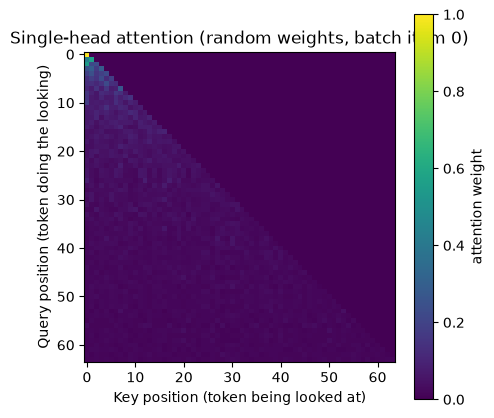

In [9]:
plt.figure(figsize=(5, 5))
plt.imshow(weights[0].detach().cpu().numpy(), cmap="viridis")
# Attention heatmap: row = query (who looks), column = key (looked at).
# Attention heatmap: row = query (who looks), column = key (looked at).
plt.title("Single-head attention (random weights, batch item 0)")
plt.xlabel("Key position (token being looked at)")
plt.ylabel("Query position (token doing the looking)")
plt.colorbar(label="attention weight")
plt.show()


## 3. Task 2 — from one head to stacked Transformer blocks

One attention head gives one "relevance pattern". Real transformers add:

- **multiple heads** — each learns its own pattern (some track spaces/newlines,
  some the current speaker, ...);
- a small **feed-forward network** per position — the "thinking" step after the
  "talking" step;
- **residual connections** around both — gradients flow and deep stacks train;
- **LayerNorm** for stable activation scales;
- **positional embeddings** — attention itself is order-blind.

### 3.1 Multi-head attention

Instead of `h` small projections, run one big projection and split it into
`h` heads of size `d_model / h`:


In [10]:
class MultiHeadSelfAttention(nn.Module):
# MULTI-HEAD: one big (C,C) projection per Q/K/V, split into h heads of
# MULTI-HEAD: one big (C,C) projection per Q/K/V, split into h heads of
    """h single heads in parallel via one big projection each."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
# Even split required: each head gets d_model/h dims.
# Even split required: each head gets d_model/h dims.
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)   # lets heads interact
# Output projection after concatenation: lets the h separate patterns
# Output projection after concatenation: lets the h separate patterns

        self.attn_drop = nn.Dropout(dropout)
# Dropout on attention WEIGHTS: randomly zeroes some attended tokens
# Dropout on attention WEIGHTS: randomly zeroes some attended tokens
        self.register_buffer(
            "mask", torch.triu(torch.ones(512, 512, dtype=torch.bool), diagonal=1)
        )

    def forward(self, x):
        B, T, C = x.shape

        # (B, T, C) -> (B, n_heads, T, d_head)
        q = self.q_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
# view+transpose reshapes (B,T,C) into per-head (B,h,T,d_head) WITHOUT
# view+transpose reshapes (B,T,C) into per-head (B,h,T,d_head) WITHOUT
        k = self.k_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        # scaled dot-product attention per head
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_head)   # (B, h, T, T)
# Same scaled dot-product as before, but d_head (not d_model) is what
# Same scaled dot-product as before, but d_head (not d_model) is what
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn = self.attn_drop(F.softmax(scores, dim=-1))

        y = attn @ v                                     # (B, h, T, d_head)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-merge the heads
# Re-merge: transpose back and .contiguous() (view needs contiguous
# Re-merge: transpose back and .contiguous() (view needs contiguous
        return self.out_proj(y)


### 3.2 The block: attention + feed-forward, both in residuals

A Transformer block has two sub-steps. Attention lets tokens **talk to each
other**; the FFN then lets each token **process** what it collected,
independently per position. Residuals (`x + f(x)`) mean each sub-step only
needs to learn a small *correction* — that is what makes deep stacks trainable.
Pre-LayerNorm (normalize *before* each sub-step) keeps scales steady.


In [11]:
class TransformerBlock(nn.Module):
# THE BLOCK: attention (tokens talk) + FFN (each token thinks), both in
# THE BLOCK: attention (tokens talk) + FFN (each token thinks), both in
    """Communication (attention) + computation (FFN), both wrapped in residuals."""

    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
# FFN: expand to 4x width (standard), GELU nonlinearity, project back.
# Applied per position independently: attention = communication, FFN =
# FFN: expand to 4x width (standard), GELU nonlinearity, project back.
# Applied per position independently: attention = communication, FFN =
            nn.Linear(d_model, 4 * d_model),   # wider inner layer (standard 4x)
            nn.GELU(),
            nn.Linear(4 * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # residual 1
# PRE-NORM: normalize BEFORE the sublayer, add the input back after.
# The residual (+) is why deep stacks train: each sublayer only learns a
# PRE-NORM: normalize BEFORE the sublayer, add the input back after.
# The residual (+) is why deep stacks train: each sublayer only learns a
        x = x + self.ffn(self.ln2(x))    # residual 2
        return x


block = TransformerBlock(d_model=64, n_heads=4)
# Smoke test: shape preserved (blocks never change shape) + param count
# Smoke test: shape preserved (blocks never change shape) + param count
x_test = torch.randn(2, 32, 64)
print(f"block: {tuple(x_test.shape)} -> {tuple(block(x_test).shape)}")
print("parameters in one block:", sum(p.numel() for p in block.parameters()))


block: (2, 32, 64) -> (2, 32, 64)
parameters in one block: 49792


### 3.3 The full model: embedding + stacked blocks + LM head

Assembly order for a decoder-only GPT:

    token ids
      -> token embedding + positional embedding
      -> N x TransformerBlock   (each causal, so the whole stack stays causal)
      -> final LayerNorm
      -> Linear projection to vocab logits

The table that maps hidden states to vocabulary logits is **tied** to the
token-embedding matrix (same weights used in both directions) — a standard
trick that saves parameters and works well at this scale.


In [12]:
class TinyGPT(nn.Module):
# THE FULL GPT: embeddings -> N blocks -> final LayerNorm -> LM head.
# Decoder-only: one stack predicts the next token; there is no encoder.
# THE FULL GPT: embeddings -> N blocks -> final LayerNorm -> LM head.
# Decoder-only: one stack predicts the next token; there is no encoder.
    """A minimal decoder-only transformer (GPT-style) built from the blocks above."""

    def __init__(self, vocab_size, d_model=128, n_heads=4, n_layers=4,
                 block_size=64, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
# Two tables: WHAT each token is (tok_emb) and WHERE it is (pos_emb).
# Two tables: WHAT each token is (tok_emb) and WHERE it is (pos_emb).
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [TransformerBlock(d_model, n_heads, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

        self.lm_head.weight = self.tok_emb.weight   # weight tying
# WEIGHT TYING: transpose of the embedding table doubles as the output
# WEIGHT TYING: transpose of the embedding table doubles as the output

        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(m):
# Init: small normal (std=0.02) for weights, zeros for biases — the GPT-2
# Init: small normal (std=0.02) for weights, zeros for biases — the GPT-2
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)

        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))   # (B, T, C)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)                               # (B, T, vocab)
# One (V,) logit row per position: T parallel next-token predictions.
# One (V,) logit row per position: T parallel next-token predictions.
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
# Flatten (B,T,V) vs (B,T) into (B*T, V) vs (B*T): all B*T predictions
# Flatten (B,T,V) vs (B,T) into (B*T, V) vs (B*T): all B*T predictions
                logits.reshape(-1, logits.size(-1)), targets.reshape(-1)
            )
        return logits, loss


In [13]:
model = TinyGPT(vocab_size, d_model=128, n_heads=4, n_layers=4, block_size=64).to(device)

n_params = sum(p.numel() for p in model.parameters())
n_unique = n_params - model.tok_emb.weight.numel()   # the tied table is counted twice
# .parameters() double-counts the tied table; subtract it once for truth.
# .parameters() double-counts the tied table; subtract it once for truth.
print(f"Parameters (tied table counted twice): {n_params:,}")
print(f"Parameters (unique):                   {n_unique:,}")

logits, loss = model(*get_batch(train_data))
print(f"logits: {tuple(logits.shape)}   initial loss: {loss.item():.4f}")
print(f"uniform-guessing loss would be: {math.log(vocab_size):.4f}")
# Baseline: an untrained model should start near ln(65) ≈ 4.17 (uniform
# Baseline: an untrained model should start near ln(65) ≈ 4.17 (uniform


Parameters (tied table counted twice): 808,385
Parameters (unique):                   800,065
logits: (32, 64, 65)   initial loss: 4.1913
uniform-guessing loss would be: 4.1744


## 4. Task 3 — training on short sequences (32–64 tokens)

Standard recipe: AdamW, gradient clipping, periodic evaluation on the held-out
slice. Note we **never shuffle into epochs** like notebook 04 — each step
samples a fresh random chunk of 64 tokens, which is simpler and works well for
language models.

Expected behaviour: the loss starts near `ln(65) ≈ 4.17` (uniform guessing)
and drops to roughly **1.5–1.8** within a few thousand steps. `BLOCK_SIZE = 64`
here; set it to 32 for a faster first run (see §6 for what to compare).


In [20]:
# --- Training configuration --------------------------------------------------
BLOCK_SIZE = 32      # context length in tokens (try 32 for faster runs)
# HYPERPARAMETERS — the knobs to experiment with (see the exercises):
# HYPERPARAMETERS — the knobs to experiment with (see the exercises):
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
MAX_STEPS = 3000     # ~5-10 min on CPU; use 500 for a quick smoke run
EVAL_INTERVAL = 300
EVAL_ITERS = 50      # batches averaged for a more stable loss estimate

model = TinyGPT(vocab_size, d_model=128, n_heads=4, n_layers=1,
# NOTE: instantiated with n_layers=1 (a 1-block model) even though 4 is
# NOTE: instantiated with n_layers=1 (a 1-block model) even though 4 is
                block_size=BLOCK_SIZE, dropout=0.1).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
# AdamW = Adam with decoupled weight decay (the modern default for
# AdamW = Adam with decoupled weight decay (the modern default for
print(f"Training on sequences of {BLOCK_SIZE} tokens, batch of {BATCH_SIZE}")


Training on sequences of 32 tokens, batch of 32


In [21]:
@torch.no_grad()
# estimate_loss: averages the loss over EVAL_ITERS fresh batches,
# estimate_loss: averages the loss over EVAL_ITERS fresh batches,
def estimate_loss(model, iters=EVAL_ITERS):
    """Average loss over fresh batches - a less noisy read on progress."""
    model.eval()
# eval() mode for honest val loss (no dropout noise), .train() again after.
# eval() mode for honest val loss (no dropout noise), .train() again after.
    out = {}
    for name, source in (("train", train_data), ("val", val_data)):
        losses = torch.zeros(iters)
        for k in range(iters):
            xb, yb = get_batch(source, BATCH_SIZE, BLOCK_SIZE)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[name] = losses.mean().item()
    model.train()
    return out


train_losses, val_losses = [], []
model.train()

for step in range(1, MAX_STEPS + 1):
    xb, yb = get_batch(train_data, BATCH_SIZE, BLOCK_SIZE)

    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # keep updates sane
# GRADIENT CLIPPING at norm 1.0: rare large-loss batches would otherwise
# GRADIENT CLIPPING at norm 1.0: rare large-loss batches would otherwise
    optimizer.step()

    train_losses.append(loss.item())

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS:
        losses = estimate_loss(model)
# Watch train vs val: a widening gap = overfitting (then raise dropout).
# Watch train vs val: a widening gap = overfitting (then raise dropout).
        val_losses.append(losses["val"])
        print(f"step {step:5d} | train {losses['train']:.4f} | val {losses['val']:.4f}")


step   300 | train 2.4413 | val 2.4509
step   600 | train 2.2341 | val 2.2533
step   900 | train 2.1323 | val 2.1696
step  1200 | train 2.0537 | val 2.0868
step  1500 | train 1.9966 | val 2.0583
step  1800 | train 1.9396 | val 2.0321
step  2100 | train 1.9065 | val 1.9988
step  2400 | train 1.8848 | val 1.9809
step  2700 | train 1.8507 | val 1.9900
step  3000 | train 1.8281 | val 1.9462


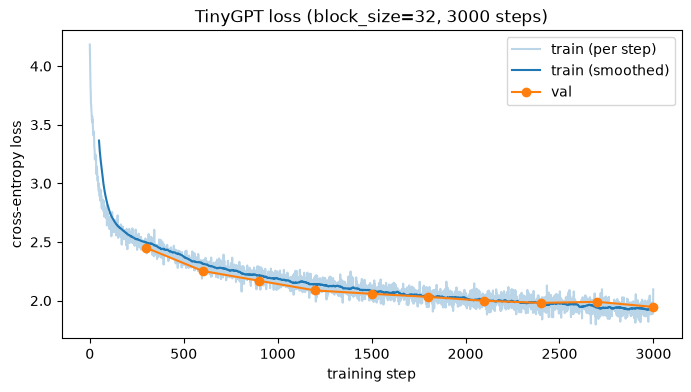

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color="tab:blue", alpha=0.3, label="train (per step)")

k = 50   # smoothing window
# np.convolve = moving average over k=50 steps: per-step train loss is
# np.convolve = moving average over k=50 steps: per-step train loss is
smooth = np.convolve(train_losses, np.ones(k) / k, mode="valid")
plt.plot(range(k - 1, len(train_losses)), smooth, color="tab:blue", label="train (smoothed)")

eval_steps = list(range(EVAL_INTERVAL, len(train_losses) + 1, EVAL_INTERVAL))
plt.plot(eval_steps[:len(val_losses)], val_losses, "o-", color="tab:orange", label="val")

plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title(f"TinyGPT loss (block_size={BLOCK_SIZE}, {MAX_STEPS} steps)")
plt.legend()
plt.show()


## 5. Generating text

Same autoregressive loop as notebook 04: predict → append → repeat. Two
differences: the context window is now up to `block_size` tokens (not 5
characters), and `top_k` sampling is available to cut off the long tail of
unlikely characters.


In [23]:
@torch.no_grad()
# GENERATION = the training shift, executed by hand: crop context ->
# GENERATION = the training shift, executed by hand: crop context ->
def generate(model, start_str="First Citizen:", max_new_tokens=400,
             temperature=0.8, top_k=None):
    """Sample from the model, one character at a time."""
    model.eval()
    idx = torch.tensor([[char_to_idx[c] for c in start_str]],
                       dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]        # crop to the context window
# Crop to block_size: the model only ever saw T tokens, so it can only
# Crop to block_size: the model only ever saw T tokens, so it can only
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature      # only the LAST position matters
# Only the LAST position's logits matter: that position has seen the
# Only the LAST position's logits matter: that position has seen the

        if top_k is not None:                        # keep only the top-k logits
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float("-inf")
# TOP-K: blank out everything below the k-th logit, renormalize over
# TOP-K: blank out everything below the k-th logit, renormalize over

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
# Append and loop: each sampled token becomes part of the next context.
# Append and loop: each sampled token becomes part of the next context.

    return "".join(idx_to_char[i.item()] for i in idx[0])


print(generate(model, "First Citizen:", max_new_tokens=400, temperature=0.8))


First Citizen:
I' with is wis and a canvoing! and I wast the we the of the with th see a with
mer:
Prercience your heare was not lephats shall'd carrd.


NORTAUMIO:
Haght with hath. Tich ourse is and with seal have usio.


RIORCEO:
If the now thou done his to beh, any a mart but and my not for again,
The war he soul mant, for the spire;
The of thou in of be morn lave me miset so face done the do I doubt as s ma


In [24]:
for prompt in ("JULIET:", "KING RICHARD III:", "\n"):
# Speaker-style prompts: the model continues speaker names with their
# Speaker-style prompts: the model continues speaker names with their
    print("=" * 60)
    print(repr(prompt))
    print("-" * 60)
    print(generate(model, prompt, max_new_tokens=250, temperature=0.8))


'JULIET:'
------------------------------------------------------------
JULIET:
I dall have
That at wil I spenthe of and they for's dey.

POLEO:
Or 'Come old to king
not the wore ward thou lie give.


LUCENTIO:
Shall spir:
That wich man'd the he grothat son din for my his brack and sove.

QUEEN ENCENTIO:
Why she drere the being
'KING RICHARD III:'
------------------------------------------------------------
KING RICHARD III:
Belt's the he putsion to he of the end pur ther of as Richle,
Oor thou the call-say of he canot ong it?


MELOUS:
What;
He deent do their thing the st
The so makem.


CORIANUS:
You leand teself I his one cour face.

LORIANGEO:
And more he hathe ust 
'\n'
------------------------------------------------------------

Thou bear red now, I aMartion! he I dear he will card of of the the have the lead with soul that so nexess Here sure forthe he hou dard,
Teres that call bear. Warwith nour what then here the der's the fing you dongith: live she with see sa s a I do m


In [19]:
print("temperature = 0.3 (focused, repetitive):")
# Side-by-side temperature comparison — the intuition builder for why
# Side-by-side temperature comparison — the intuition builder for why
print(generate(model, "First Citizen:", max_new_tokens=250, temperature=0.3))
print()
print("temperature = 1.2 (creative, chaotic):")
print(generate(model, "First Citizen:", max_new_tokens=250, temperature=1.2))


temperature = 0.3 (focused, repetitive):
First Citizen:
The love the strike for the have been a so the good
Which he shall be the love of the provers the world
That shall be the part of the grace of be the be so
What I have be be to the prince of the courter,
And thou have and stoong be the see the world

temperature = 1.2 (creative, chaotic):
First Citizen:
For was only's fardnir: to should,
Which else while hlowester is:
A whring  shell'd ever yous!-To sidreacht have could thee.

FRIAR LAUR:
Well, Romeoo, not nabe!
It hy be, this sotter, was me.
That hathd have mode in vientitur, we'll,
Henglow's ceea


## 6. Exercises

1. **Context length**: set `BLOCK_SIZE = 32`, retrain, compare val loss and
   text quality with 64. Where exactly does the longer context help?
2. **Depth**: `n_layers = 1` vs 4 — how does the val-loss curve change?
3. **Heads**: `n_heads = 1` vs 4 at fixed `d_model` — does multi-head win here?
4. **Look inside a trained head** (compare with the random-weight plot in §2):

   ```python
   with torch.no_grad():
       idx = xb[:1]                                   # one batch row
       x = model.tok_emb(idx) + model.pos_emb(torch.arange(idx.shape[1], device=device))
       _, w = model.blocks[0].attn(model.blocks[0].ln1(x))
       plt.imshow(w[0, 0].cpu())                      # layer 1, head 0
   ```
5. **Regularization**: dropout 0.0 vs 0.2 — watch the train/val gap.
6. **Sampling**: try `top_k=10` vs `None` in §5 — which text reads better?


## 7. Key takeaways

- Self-attention is a **dynamic, content-based weighted average** over previous
  tokens; an MLP's fixed weights cannot do this.
- The **causal mask** is what turns a Transformer into a language model:
  predict every next token in parallel, but never see the future.
- A Transformer **block** = communication (attention) + computation (FFN),
  both wrapped in residuals and LayerNorm; stack N of them → GPT.
- Batches of short sequences give **T parallel predictions** per sequence —
  the shift from notebook 04's "5 chars → 1 next char".
- Natural next steps: swap characters for BPE subwords (see notebook 04),
  encoder-decoder cross-attention, sinusoidal/RoPE position encodings,
  learning-rate schedules, and scaling up.
